# Train and Tune FF MLP Model

In [1]:
from pathlib import Path

import optuna.visualization as vis
import pandas as pd

from config.config import Config
from src.models.factory import Experiment
from src.models.mlp import MLP
from src.plots import plot_forecast_diagnostics, plot_forecast_next_h, plot_test_overlay_h1, prep_h1_overlay, \
    prep_h_overlay
from src.runners import run_experiments
from src.utils import set_seed

In [2]:
cfg = Config(Path("../config/config.yaml"))
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
rng = set_seed(SEED)

2025-08-27 16:55:38,154 - INFO - src.utils - Global random seed set to 42


In [3]:
df_full = pd.read_csv(Path(cfg.data.processed_dir) / "features_full.csv")

In [4]:
experiments = [
    Experiment(
        name="mlp",
        build=lambda horizon, seed: MLP(horizon=horizon, random_state=seed),
        include_sentiment=True
    )
]

In [5]:
results = run_experiments(df_full, Path(cfg.data.processed_dir), experiments, HORIZON, SEED)

2025-08-27 16:55:38,259 - INFO - ModelTrainer - Initialized ModelTrainer for model: mlp
D:\IntelliJ\ml-stock-sent\.venv\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
D:\IntelliJ\ml-stock-sent\.venv\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``constant_liar`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-08-27 16:55:38,260] A new study created in memory with name: no-name-0f0cd93b-cc95-4105-93bd-1713fb1b2946
2025-08-27 16:55:38,260 - INFO - ModelTrainer - Starting model tuning...
D:\IntelliJ\ml-stock-sent\.venv\Lib\site-packages\optuna\distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (128,) which is of type tuple.
  warnings.warn(message)
D:\IntelliJ\ml-stock-sent\.ve

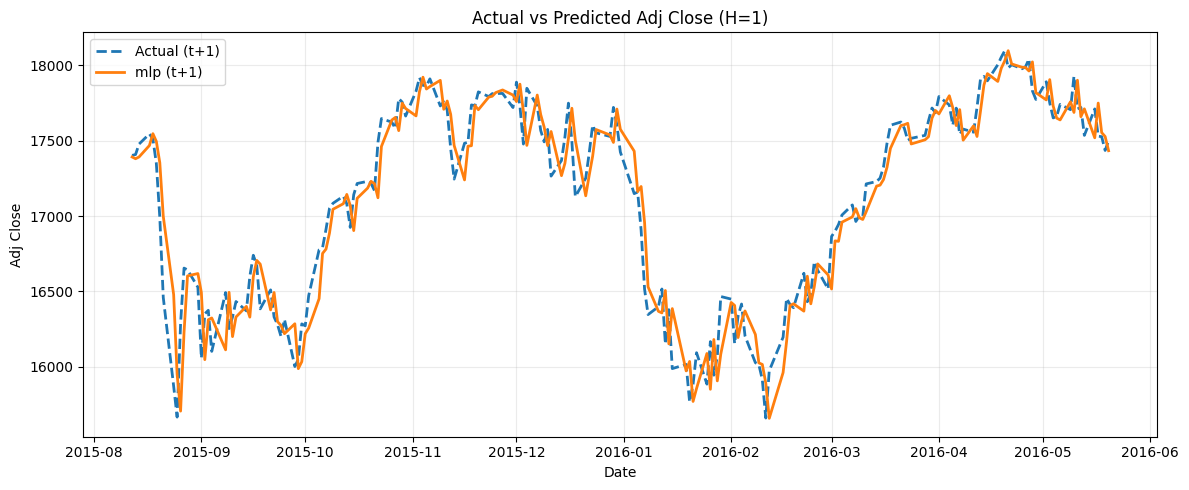

In [6]:
dates_next, actual_next, pred_next_by_model = prep_h1_overlay(df_full, results)
plot_test_overlay_h1(
    dates_next=dates_next,
    actual_next=actual_next,
    pred_next_by_model=pred_next_by_model,
    path=Path(cfg.data.fig_dir) / "mlp_actual_vs_predicted_adj_close.png",
)

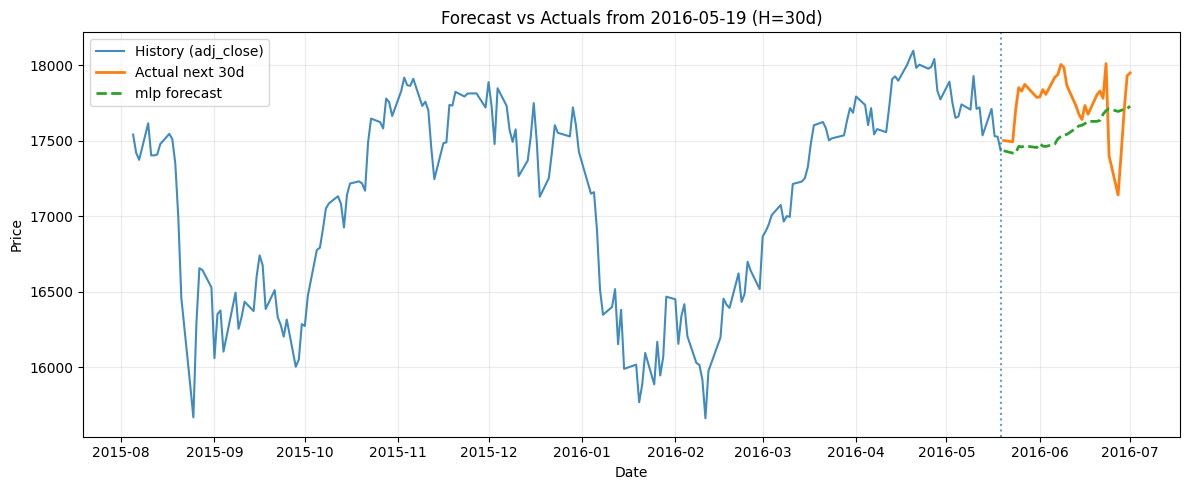

In [7]:
hist_dates, hist_prices, fut_dates, actual_path, anchor_date, paths_by_model = prep_h_overlay(df_full, results, HORIZON)
plot_forecast_next_h(
    hist_dates=hist_dates,
    hist_prices=hist_prices,
    fut_dates=fut_dates,
    forecast_paths_by_model=paths_by_model,
    actual_path=actual_path,
    anchor_date=anchor_date,
    H=HORIZON,
    path=Path(cfg.data.fig_dir) / "mlp_forecast.png",
)

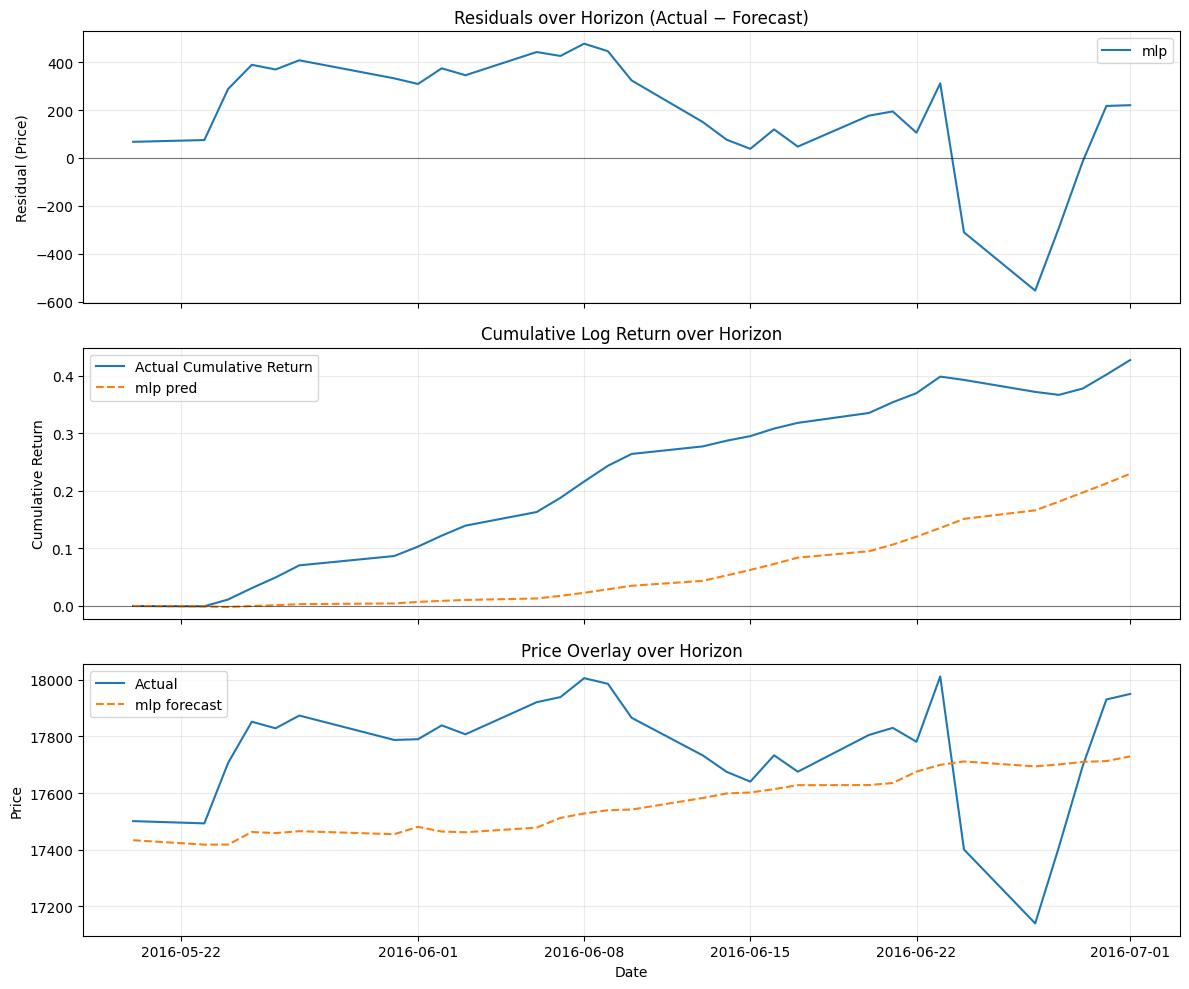

In [8]:
plot_forecast_diagnostics(
    fut_dates=fut_dates,
    actual_path=actual_path,
    forecast_paths_by_model=paths_by_model,
    path=Path(cfg.data.fig_dir) / "mlp_forecast_diagnostics.png",
)

In [9]:
pd.DataFrame(results[0]["best_params"])

,hidden_layer_sizes,activation,solver,alpha,max_iter,tol,learning_rate_init,learning_rate,batch_size,early_stopping,n_iter_no_change,validation_fraction,shuffle,random_state
0,256,relu,adam,8.233722e-07,600,0.000085,0.002931,constant,512,True,14,0.15,False,42
1,128,relu,adam,8.233722e-07,600,0.000085,0.002931,constant,512,True,14,0.15,False,42
2,64,relu,adam,8.233722e-07,600,0.000085,0.002931,constant,512,True,14,0.15,False,42


In [10]:
pd.DataFrame(results[0]["metrics"]["test"], index=[0])

,mae,mse,rmse,smape,r2
0,0.007664,0.000101,0.010043,1.676168,-0.014575


In [11]:
study = results[0]["study"]

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()
vis.plot_slice(study).show()
vis.plot_parallel_coordinate(study).show()
vis.plot_contour(study).show()
vis.plot_edf(study).show()